In [1]:
import os
import re
import pandas as pd
import numpy as np
from itertools import combinations
import matplotlib.pyplot as plt
from sklearn.metrics import cohen_kappa_score
from IPython.display import display

# ======= CONFIG (sesuaikan nama file bila perlu) =======
FILES = [
    "shopee_reviews_phase2-labeled.csv",
    "hasil label shopee_reviews_phase2 - Matius Samuel Paulus.csv",
    "label shopee_reviews_phase2 - Aurellia Cindy.csv"
]

INPUT_DIR = "/kaggle/input/e-commerce-review"      # direktori dataset Anda di Kaggle
OUT_SUMMARY = "/kaggle/working/kappa_summary_per_aspect_three_annotators.csv"
OUT_PAIRWISE = "/kaggle/working/kappa_pairwise_details_three_annotators.csv"
OUT_DISAGREEMENTS = "/kaggle/working/disagreements_per_aspect.csv"

# Kolom aspek — gunakan nama persis seperti pada file Anda
ASPECT_COLS = ['Aplikasi', 'Pengiriman', 'Produk', 'Harga', 'Pembayaran', 'Layanan Pelanggan (CS)', 'Penjual']

# Nama kolom kunci yang Anda sediakan
ID_COL = "reviewId"
TEXT_COL = "content"

# Annotator display names (user-requested)
ANNOTATOR_NAMES = ["Bernardo", "Samuel", "Aurel"]

print("Konfigurasi siap. Pastikan tiga file ada di:", INPUT_DIR)
print("Files:", FILES)
print("Aspek:", ASPECT_COLS)
print("Annotators:", ANNOTATOR_NAMES)

Konfigurasi siap. Pastikan tiga file ada di: /kaggle/input/e-commerce-review
Files: ['shopee_reviews_phase2-labeled.csv', 'hasil label shopee_reviews_phase2 - Matius Samuel Paulus.csv', 'label shopee_reviews_phase2 - Aurellia Cindy.csv']
Aspek: ['Aplikasi', 'Pengiriman', 'Produk', 'Harga', 'Pembayaran', 'Layanan Pelanggan (CS)', 'Penjual']
Annotators: ['Bernardo', 'Samuel', 'Aurel']


In [2]:
# Fungsi load_and_merge_with_annotator_names:
# - Membaca beberapa file anotasi (CSV) dari sebuah direktori input dan memberi nama kolom spesifik
#   untuk setiap annotator agar kolom tidak bertabrakan.
# - files: list nama file (mis. ['ann1.csv','ann2.csv',...])
# - input_dir: folder tempat file-file berada
# - annotator_names: list nama annotator (harus sepanjang files) seperti ['A','B','C']
# Proses:
# 1. Untuk tiap file: baca CSV (coba utf-8, fallback latin1), isi NaN dengan empty string.
# 2. Validasi: pastikan setiap dataframe memiliki kolom ID_COL, TEXT_COL dan semua ASPECT_COLS.
#    Jika kolom hilang, fungsi akan melempar ValueError yang menyebut file bermasalah.
# 3. Rename kolom (selain kolom ID_COL) dengan menambah suffix "__{annotator}" sehingga mudah
#    membedakan jawaban dari annotator yang berbeda.
# 4. Merge semua dataframe secara outer join pada kolom ID_COL (preserve semua baris dari semua annotator).
# Return: dataframe hasil merge.
# Side-effects: mencetak status loading tiap file.
# Catatan: ID_COL, TEXT_COL, ASPECT_COLS, FILES, INPUT_DIR, dan ANNOTATOR_NAMES diasumsikan didefinisikan
# di luar fungsi (seperti pada skrip Anda). Jika tidak, definisikan sebelum memanggil fungsi.
def load_and_merge_with_annotator_names(files, input_dir, annotator_names):
    dfs = []
    for fn in files:
        p = os.path.join(input_dir, fn)
        if not os.path.exists(p):
            raise FileNotFoundError(f"File tidak ditemukan: {p}")
        try:
            df = pd.read_csv(p, dtype=str, encoding='utf-8', engine='python')
        except Exception:
            df = pd.read_csv(p, dtype=str, encoding='latin1', engine='python')
        dfs.append(df.fillna(""))  # isi NaN dgn empty string supaya seragam
        print("Loaded:", fn, "shape:", dfs[-1].shape)
    # validate columns
    for i, df in enumerate(dfs, start=1):
        missing = []
        if ID_COL not in df.columns: missing.append(ID_COL)
        if TEXT_COL not in df.columns: missing.append(TEXT_COL)
        for a in ASPECT_COLS:
            if a not in df.columns: missing.append(a)
        if missing:
            raise ValueError(f"DF{i} kehilangan kolom: {missing}. Periksa file {files[i-1]}")
    # rename columns per annotator (preserve reviewId)
    renamed = []
    for i, df in enumerate(dfs):
        ann = annotator_names[i]
        def ren(c):
            return c if c == ID_COL else f"{c}__{ann}"
        renamed.append(df.rename(columns=lambda c: ren(c)))
    # merge outer on reviewId
    merged = renamed[0]
    for i in range(1, len(renamed)):
        merged = merged.merge(renamed[i], on=ID_COL, how='outer')
    return merged

merged = load_and_merge_with_annotator_names(FILES, INPUT_DIR, ANNOTATOR_NAMES)
print("Merged shape:", merged.shape)
display(merged[[ID_COL, f"{TEXT_COL}__{ANNOTATOR_NAMES[0]}", f"{TEXT_COL}__{ANNOTATOR_NAMES[1]}", f"{TEXT_COL}__{ANNOTATOR_NAMES[2]}"]].head(5))

Loaded: shopee_reviews_phase2-labeled.csv shape: (1043, 17)
Loaded: hasil label shopee_reviews_phase2 - Matius Samuel Paulus.csv shape: (1043, 17)
Loaded: label shopee_reviews_phase2 - Aurellia Cindy.csv shape: (1043, 17)
Merged shape: (1044, 49)


,reviewId,content__Bernardo,content__Samuel,content__Aurel
0,0,pelit hadiah nya dan lemot... harus segera dip...,NaN,pelit hadiah nya dan lemot... harus segera dip...
1,006308e2-0484-4ad7-94c6-9dd0965702ad,bagus banget barang barang yg di jual murah murah,bagus banget barang barang yg di jual murah murah,bagus banget barang barang yg di jual murah murah
2,008e61c7-f98f-4c3f-85bc-3fe9366b409a,sangat puas atas pelayanan dan produk2nya sesu...,sangat puas atas pelayanan dan produk2nya sesu...,sangat puas atas pelayanan dan produk2nya sesu...
3,00d6935d-dca3-44ca-9dc2-311b4c04ff26,barang sering tidak sampai karena hilang selam...,barang sering tidak sampai karena hilang selam...,barang sering tidak sampai karena hilang selam...
4,00dbeed3-0721-4ffd-bf2a-4d6f959f14df,belanja di shopee suka bgt ongkir nya kecil dr...,belanja di shopee suka bgt ongkir nya kecil dr...,belanja di shopee suka bgt ongkir nya kecil dr...


In [3]:
# Fungsi normalize_to_P_N_I:
# Normalisasi label sentimen mentah ke dalam tiga kategori tetap:
#   - 'P' untuk positif
#   - 'N' untuk negatif
#   - 'I' (ignore/netral) untuk semua nilai lain atau None
# Berguna agar anotasi yang berbeda format tetap seragam.
def normalize_to_P_N_I(raw):
    if raw is None:
        return 'I'
    s = str(raw).strip().upper()
    if s == 'P':
        return 'P'
    if s == 'N':
        return 'N'
    return 'I'
# Fungsi fleiss_kappa_general:
# Menghitung nilai Fleiss' Kappa untuk menilai kesepakatan antar-anotator
# pada data kategorikal dengan banyak rater per item.
# Parameter:
#   - counts_matrix: matriks 2D (N x k), berisi jumlah label per kategori untuk tiap item
# Return:
#   - Nilai kappa (float) atau NaN jika data tidak valid
# Catatan: fungsi akan mengembalikan NaN bila jumlah rater tidak konsisten antar item.
def fleiss_kappa_general(counts_matrix):
    counts = np.asarray(counts_matrix, dtype=float)
    if counts.size == 0:
        return np.nan
    N, k = counts.shape
    n_raters = counts.sum(axis=1)
    if not np.allclose(n_raters, n_raters[0]):  # requirement: same #raters per item
        return np.nan
    n = n_raters[0]
    if n <= 1:
        return np.nan
    p = counts.sum(axis=0) / (N * n)
    P_i = ( (counts * (counts - 1)).sum(axis=1) ) / (n * (n - 1))
    P_bar = P_i.mean()
    P_e = (p ** 2).sum()
    if 1 - P_e == 0:
        return np.nan
    return (P_bar - P_e) / (1 - P_e)

In [4]:
summary_rows = []
pairwise_rows = []
disagreement_2v1_rows = []
disagreement_all_rows = []

categories = ['P', 'N', 'I']  # category order for counts

for aspect in ASPECT_COLS:
    colA = f"{aspect}__{ANNOTATOR_NAMES[0]}"
    colB = f"{aspect}__{ANNOTATOR_NAMES[1]}"
    colC = f"{aspect}__{ANNOTATOR_NAMES[2]}"

    print(f"\nProcessing aspect: {aspect}")

    # prepare normalized series (map missing/NaN to empty string first)
    sA_raw = merged[colA] if colA in merged.columns else pd.Series([""] * len(merged), index=merged.index)
    sB_raw = merged[colB] if colB in merged.columns else pd.Series([""] * len(merged), index=merged.index)
    sC_raw = merged[colC] if colC in merged.columns else pd.Series([""] * len(merged), index=merged.index)

    sA_norm = sA_raw.apply(normalize_to_P_N_I)
    sB_norm = sB_raw.apply(normalize_to_P_N_I)
    sC_norm = sC_raw.apply(normalize_to_P_N_I)

    # Pairwise Cohen: compute on full arrays (no missing because normalize maps to 'I')
    pairs = [
        (ANNOTATOR_NAMES[0], sA_norm),
        (ANNOTATOR_NAMES[1], sB_norm),
        (ANNOTATOR_NAMES[2], sC_norm),
    ]

    for (nameA, seriesA), (nameB, seriesB) in combinations(pairs, 2):
        # convert to numeric codes for cohen_kappa_score or use string arrays — both work
        a_vals = seriesA.map({'P': 0, 'N': 1, 'I': 2}).astype(int)
        b_vals = seriesB.map({'P': 0, 'N': 1, 'I': 2}).astype(int)

        # compute on all rows (since no missing)
        kappa = cohen_kappa_score(a_vals, b_vals)
        n_total = len(a_vals)

        pairwise_rows.append({
            'aspect': aspect,
            'pair': f"{nameA}__vs__{nameB}",
            'n_total_rows': n_total,
            'cohen_kappa_including_invalid': kappa,
        })

    # Fleiss: build counts for categories per row
    counts = []
    for idx in merged.index:
        labA = sA_norm.at[idx]
        labB = sB_norm.at[idx]
        labC = sC_norm.at[idx]

        row_counts = [0] * len(categories)
        for lab in (labA, labB, labC):
            j = categories.index(lab)
            row_counts[j] += 1

        counts.append(row_counts)

    counts = np.array(counts)
    fleiss = fleiss_kappa_general(counts)

    # summary statistics
    # category distribution overall
    flat = np.concatenate([sA_norm.values, sB_norm.values, sC_norm.values])
    dist = {cat: int((flat == cat).sum()) for cat in categories}

    summary_rows.append({
        'aspect': aspect,
        'n_items_merged': len(merged),
        'total_labels_count': int(flat.size),
        'count_P': dist['P'],
        'count_N': dist['N'],
        'count_INVALID': dist['I'],
        'fleiss_kappa_including_invalid': fleiss,
    })

    # -----------------------------------------------------------------
    # NEW: collect disagreements into two separate lists:
    #   - disagreement_2v1_rows  (two annotators agree, one disagrees)
    #   - disagreement_all_rows  (all three annotators different)
    # -----------------------------------------------------------------
    from collections import Counter

    for idx in merged.index:
        labA = sA_norm.at[idx]
        labB = sB_norm.at[idx]
        labC = sC_norm.at[idx]

        labs_dict = {
            ANNOTATOR_NAMES[0]: labA,
            ANNOTATOR_NAMES[1]: labB,
            ANNOTATOR_NAMES[2]: labC,
        }

        # skip unanimous
        if len(set(labs_dict.values())) == 1:
            continue

        # prefer content from Bernardo then Samuel then Aurel
        content_val = None
        for ccol in (
            f"{TEXT_COL}__{ANNOTATOR_NAMES[0]}",
            f"{TEXT_COL}__{ANNOTATOR_NAMES[1]}",
            f"{TEXT_COL}__{ANNOTATOR_NAMES[2]}",
        ):
            if ccol in merged.columns and pd.notna(merged.at[idx, ccol]) and merged.at[idx, ccol] != "":
                content_val = merged.at[idx, ccol]
                break

        cnt = Counter(labs_dict.values())
        unique_labels = list(cnt.keys())

        if len(unique_labels) == 2:
            # two agree, one disagrees
            majority_label, _ = cnt.most_common(1)[0]
            minority_label = [lab for lab in unique_labels if lab != majority_label][0]

            majority_annotators = [name for name, lab in labs_dict.items() if lab == majority_label]
            minority_annotators = [name for name, lab in labs_dict.items() if lab == minority_label]

            disagreement_2v1_rows.append({
                'reviewId': merged.at[idx, ID_COL] if ID_COL in merged.columns else None,
                'aspect': aspect,
                f'raw_{ANNOTATOR_NAMES[0]}': sA_raw.at[idx],
                f'raw_{ANNOTATOR_NAMES[1]}': sB_raw.at[idx],
                f'raw_{ANNOTATOR_NAMES[2]}': sC_raw.at[idx],
                f'norm_{ANNOTATOR_NAMES[0]}': labA,
                f'norm_{ANNOTATOR_NAMES[1]}': labB,
                f'norm_{ANNOTATOR_NAMES[2]}': labC,
                'disagreement_type': '2-agree-1-disagree',
                'majority_label': majority_label,
                'majority_annotators': "|".join(majority_annotators),
                'minority_label': minority_label,
                'minority_annotator': minority_annotators[0] if len(minority_annotators) == 1 else "|".join(minority_annotators),
                'types_set': "|".join(sorted(list(set((labA, labB, labC))))),
                'content': content_val,
            })

        else:
            # all three different
            disagreement_all_rows.append({
                'reviewId': merged.at[idx, ID_COL] if ID_COL in merged.columns else None,
                'aspect': aspect,
                f'raw_{ANNOTATOR_NAMES[0]}': sA_raw.at[idx],
                f'raw_{ANNOTATOR_NAMES[1]}': sB_raw.at[idx],
                f'raw_{ANNOTATOR_NAMES[2]}': sC_raw.at[idx],
                f'norm_{ANNOTATOR_NAMES[0]}': labA,
                f'norm_{ANNOTATOR_NAMES[1]}': labB,
                f'norm_{ANNOTATOR_NAMES[2]}': labC,
                'disagreement_type': 'all-different',
                'labels_per_annotator': "|".join([f"{n}:{l}" for n, l in labs_dict.items()]),
                'types_set': "|".join(sorted(list(set((labA, labB, labC))))),
                'content': content_val,
            })

# Save outputs
df_summary = pd.DataFrame(summary_rows)
df_pairs = pd.DataFrame(pairwise_rows)

# --- build DataFrames for the two disagreement types ---
df_disagree_2v1 = pd.DataFrame(disagreement_2v1_rows)
df_disagree_all = pd.DataFrame(disagreement_all_rows)

df_summary.to_csv(OUT_SUMMARY, index=False, encoding='utf-8-sig')
df_pairs.to_csv(OUT_PAIRWISE, index=False, encoding='utf-8-sig')


print("\n=== SUMMARY (per aspect) ===")
display(df_summary)
print("\n=== PAIRWISE sample ===")
display(df_pairs.head(40))

# optional: reset index / sort by aspect / reviewId for readability
if not df_disagree_2v1.empty:
    df_disagree_2v1 = df_disagree_2v1.sort_values(['aspect', 'reviewId']).reset_index(drop=True)
if not df_disagree_all.empty:
    df_disagree_all = df_disagree_all.sort_values(['aspect', 'reviewId']).reset_index(drop=True)

# save to separate CSV files
OUT_DISAGREEMENTS_2V1 = "/kaggle/working/disagreements_2agree_1disagree.csv"
OUT_DISAGREEMENTS_ALLDIFF = "/kaggle/working/disagreements_all_different.csv"

df_disagree_2v1.to_csv(OUT_DISAGREEMENTS_2V1, index=False, encoding='utf-8-sig')
df_disagree_all.to_csv(OUT_DISAGREEMENTS_ALLDIFF, index=False, encoding='utf-8-sig')

pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

# Show brief samples
print("\n=== DISAGREEMENTS: 2-agree-1-disagree (sample) ===")
display(df_disagree_2v1)
print("len df_disagree_2v1 =", len(df_disagree_2v1))

print("\n=== DISAGREEMENTS: all-different (sample) ===")
display(df_disagree_all)
print("len df_disagree_all =", len(df_disagree_all))

print("Saved disagreements to:")
print(" - 2-agree-1-disagree:", OUT_DISAGREEMENTS_2V1)
print(" - all-different:", OUT_DISAGREEMENTS_ALLDIFF)


print("\nSaved files:")
print(" - summary:", OUT_SUMMARY)
print(" - pairwise details:", OUT_PAIRWISE)
print(" - disagreements:", OUT_DISAGREEMENTS)


Processing aspect: Aplikasi

Processing aspect: Pengiriman

Processing aspect: Produk

Processing aspect: Harga

Processing aspect: Pembayaran

Processing aspect: Layanan Pelanggan (CS)

Processing aspect: Penjual

=== SUMMARY (per aspect) ===


,aspect,n_items_merged,total_labels_count,count_P,count_N,count_INVALID,fleiss_kappa_including_invalid
0,Aplikasi,1044,3132,858,496,1778,0.923717
1,Pengiriman,1044,3132,311,384,2437,0.932632
2,Produk,1044,3132,302,85,2745,0.905002
3,Harga,1044,3132,682,80,2370,0.952864
4,Pembayaran,1044,3132,71,102,2959,0.927605
5,Layanan Pelanggan (CS),1044,3132,270,101,2761,0.976173
6,Penjual,1044,3132,34,116,2982,0.937533



=== PAIRWISE sample ===


,aspect,pair,n_total_rows,cohen_kappa_including_invalid
0,Aplikasi,Bernardo__vs__Samuel,1044,0.908586
1,Aplikasi,Bernardo__vs__Aurel,1044,0.963548
2,Aplikasi,Samuel__vs__Aurel,1044,0.899023
3,Pengiriman,Bernardo__vs__Samuel,1044,0.908648
4,Pengiriman,Bernardo__vs__Aurel,1044,0.986585
5,Pengiriman,Samuel__vs__Aurel,1044,0.905497
6,Produk,Bernardo__vs__Samuel,1044,0.864270
7,Produk,Bernardo__vs__Aurel,1044,0.987533
8,Produk,Samuel__vs__Aurel,1044,0.858324
9,Harga,Bernardo__vs__Samuel,1044,0.936375



=== DISAGREEMENTS: 2-agree-1-disagree (sample) ===


,reviewId,aspect,raw_Bernardo,raw_Samuel,raw_Aurel,norm_Bernardo,norm_Samuel,norm_Aurel,disagreement_type,majority_label,majority_annotators,minority_label,minority_annotator,types_set,content
0,0,Aplikasi,N,NaN,N,N,I,N,2-agree-1-disagree,N,Bernardo|Aurel,I,Samuel,I|N,pelit hadiah nya dan lemot... harus segera dip...
1,02ba95ff-f1e2-46e3-8526-04df8dc9b485,Aplikasi,P,0,P,P,I,P,2-agree-1-disagree,P,Bernardo|Aurel,I,Samuel,I|P,"gratis ongkir,mudah dan terpercaya"
2,086ea17f-ddfe-49ef-a5c5-85c332b17bd0,Aplikasi,P,0,P,P,I,P,2-agree-1-disagree,P,Bernardo|Aurel,I,Samuel,I|P,"mudah dan amanah murah lagi ,,,,"
3,09bffe95-da9f-4c6a-acd6-26b8ddcedd31,Aplikasi,0,N,N,I,N,N,2-agree-1-disagree,N,Samuel|Aurel,I,Bernardo,I|N,"saya ikut shopee affiliate biasa, disaat sudah..."
4,0e05dfbc-748f-458c-9045-a85bbe4971db,Aplikasi,0,N,0,I,N,I,2-agree-1-disagree,I,Bernardo|Aurel,N,Samuel,I|N,"Aneh,dulu beli pake sistem cod bisa di semua p..."
5,0fcad93e-311f-4991-aee3-fcc0c0e7a7f2,Aplikasi,0,0,N,I,I,N,2-agree-1-disagree,I,Bernardo|Samuel,N,Aurel,I|N,Tolong dong Shopee cantumin no kurir biar bisa...
6,12b69c1b-5f37-434c-9778-67e1dcdf79be,Aplikasi,N,N,0,N,N,I,2-agree-1-disagree,N,Bernardo|Samuel,I,Aurel,I|N,lama lama amplikasi ini sangat buruk. jika ada...
7,141a6e25-b312-4f3a-abff-328d39e86b07,Aplikasi,0,N,0,I,N,I,2-agree-1-disagree,I,Bernardo|Aurel,N,Samuel,I|N,"sangat di sayangkan, kinerja expedisi SPX nya ..."
8,1447a8a9-d741-48ba-ab08-8eafe4380ad5,Aplikasi,0,N,0,I,N,I,2-agree-1-disagree,I,Bernardo|Aurel,N,Samuel,I|N,aplikasi sampah .. penipuan..banyak barang ga ...
9,17270825-ed41-4450-b85e-95ab25d2cf11,Aplikasi,P,0,P,P,I,P,2-agree-1-disagree,P,Bernardo|Aurel,I,Samuel,I|P,"Bagus donkz, cuma akhir2 ini pengiriman diluar..."


len df_disagree_2v1 = 198

=== DISAGREEMENTS: all-different (sample) ===


""


len df_disagree_all = 0
Saved disagreements to:
 - 2-agree-1-disagree: /kaggle/working/disagreements_2agree_1disagree.csv
 - all-different: /kaggle/working/disagreements_all_different.csv

Saved files:
 - summary: /kaggle/working/kappa_summary_per_aspect_three_annotators.csv
 - pairwise details: /kaggle/working/kappa_pairwise_details_three_annotators.csv
 - disagreements: /kaggle/working/disagreements_per_aspect.csv


In [5]:
# Quick overall stats print (menggunakan kolom dari df_summary jika tersedia)
try:
    totP = int(df_summary['count_P'].sum()) if 'count_P' in df_summary.columns else None
    totN = int(df_summary['count_N'].sum()) if 'count_N' in df_summary.columns else None
    totI = int(df_summary['count_INVALID'].sum()) if 'count_INVALID' in df_summary.columns else None
    print("\nQuick totals per category across all aspects (from summary):")
    print(f" Total P labels: {totP}")
    print(f" Total N labels: {totN}")
    print(f" Total INVALID labels: {totI}")
except Exception as e:
    print("Could not compute quick totals from df_summary:", e)



Quick totals per category across all aspects (from summary):
 Total P labels: 2528
 Total N labels: 1364
 Total INVALID labels: 18032


Shape: (1043, 17)
Columns (sample): ['reviewId', 'userName', 'userImage', 'content', 'score', 'reviewCreatedVersion', 'at', 'replyContent', 'repliedAt', 'matched_aspects', 'Aplikasi', 'Pengiriman', 'Produk', 'Harga', 'Pembayaran', 'Layanan Pelanggan (CS)', 'Penjual']

Detected columns for aspects:
  - Aplikasi -> Aplikasi
  - Pengiriman -> Pengiriman
  - Produk -> Produk
  - Harga -> Harga
  - Pembayaran -> Pembayaran
  - Layanan Pelanggan (CS) -> Layanan Pelanggan (CS)
  - Penjual -> Penjual


,aspect,column,n_total_rows,n_P,n_N,n_unlabeled,pct_P,pct_N,pct_unlabeled,majority_label,minority_label,minority_pct,imbalance_ratio,flag_imbalanced
0,Aplikasi,Aplikasi,1043,292,163,588,0.2800,0.1563,0.5638,P,N,0.3582,1.7914,balanced
1,Pengiriman,Pengiriman,1043,95,127,821,0.0911,0.1218,0.7872,N,P,0.4279,1.3368,balanced
2,Produk,Produk,1043,103,32,908,0.0988,0.0307,0.8706,P,N,0.2370,3.2188,balanced
3,Harga,Harga,1043,230,28,785,0.2205,0.0268,0.7526,P,N,0.1085,8.2143,imbalanced
4,Pembayaran,Pembayaran,1043,24,35,984,0.0230,0.0336,0.9434,N,P,0.4068,1.4583,balanced
5,Layanan Pelanggan (CS),Layanan Pelanggan (CS),1043,89,34,920,0.0853,0.0326,0.8821,P,N,0.2764,2.6176,balanced
6,Penjual,Penjual,1043,11,41,991,0.0105,0.0393,0.9501,N,P,0.2115,3.7273,balanced


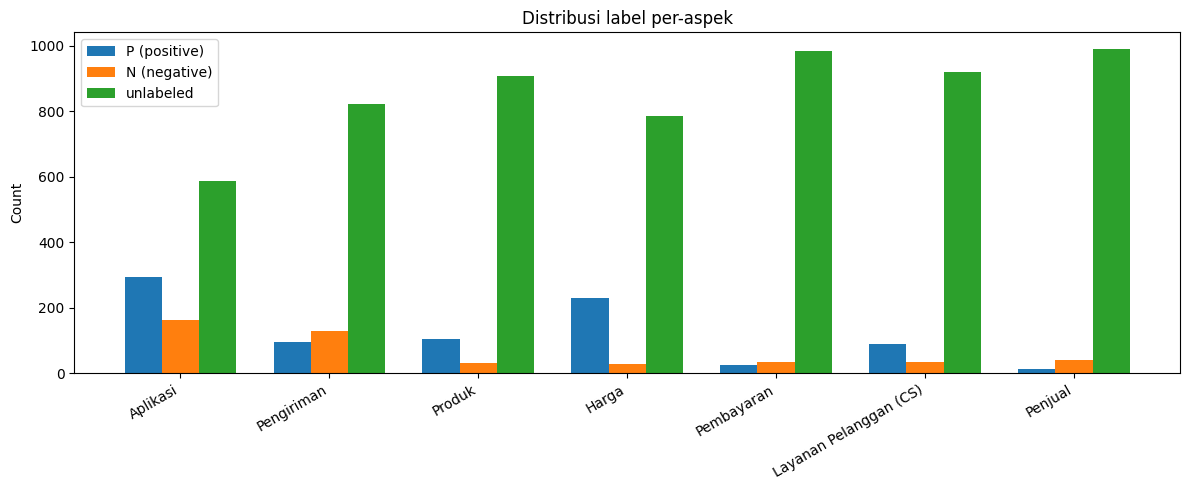

Saved summary CSV to: /kaggle/working/eda_label_distribution_per_aspect.csv


In [6]:
df = pd.read_csv('/kaggle/input/e-commerce-review-fixed/shopee_reviews_phase2-labeled-Fixed.csv')
OUT_SUMMARY_CSV = "/kaggle/working/eda_label_distribution_per_aspect.csv"

# ---------- Konfigurasi aspek & ambang ----------
ASPECTS_WANTED = [
    'Aplikasi', 'Pengiriman', 'Produk', 'Harga',
    'Pembayaran', 'Layanan Pelanggan (CS)', 'Penjual'
]
MINORITY_PERCENT_THRESHOLD = 0.20  # jika minority% < 20% -> dianggap imbalanced
IMBALANCE_RATIO_THRESHOLD = 4.0    # jika majority/minority > 4 -> sangat imbalanced

# ---------- Fungsi pembantu ----------
# Input: nama aspek (string), daftar kolom dataframe
# Proses: cari kolom yang paling cocok (exact match, substring, normalisasi)
# Strategi pencarian:
# 1. Exact match (case-insensitive)
# 2. Mencari kolom yang mengandung substring aspek (pilih yang terpendek/teratur)
# 3. Normalisasi non-alphanumeric lalu cocokkan
# Output: nama kolom dataframe yang dipilih atau None
# Kegunaan: menangani variasi kecil penamaan kolom di CSV Anda
def find_best_column(aspect_name, df_columns):
    # exact match first (case-insensitive)
    for c in df_columns:
        if c.strip().lower() == aspect_name.strip().lower():
            return c
    # contains aspect substring
    lower = aspect_name.strip().lower()
    cand = [c for c in df_columns if lower in c.lower()]
    if cand:
        cand = sorted(cand, key=lambda x: (len(x), x))
        return cand[0]
    # try remove non-alnum and compare
    norm_cols = {re.sub(r'[^a-z0-9]', '', c.lower()): c for c in df_columns}
    key = re.sub(r'[^a-z0-9]', '', aspect_name.lower())
    if key in norm_cols:
        return norm_cols[key]
    return None

print("Shape:", df.shape)
print("Columns (sample):", df.columns.tolist()[:40])

# ---------- Detect columns for each aspect ----------
aspect_col_map = {}
for asp in ASPECTS_WANTED:
    col = find_best_column(asp, df.columns.tolist())
    aspect_col_map[asp] = col

print("\nDetected columns for aspects:")
for asp, col in aspect_col_map.items():
    print(f"  - {asp} -> {col}")

# ---------- Compute distribution per aspect ----------
rows = []
for asp, col in aspect_col_map.items():
    if col is None:
        rows.append({
            'aspect': asp, 'column': None,
            'n_total_rows': len(df),
            'n_P': np.nan, 'n_N': np.nan, 'n_unlabeled': np.nan,
            'pct_P': np.nan, 'pct_N': np.nan, 'pct_unlabeled': np.nan,
            'majority_label': None, 'minority_label': None,
            'minority_pct': np.nan, 'imbalance_ratio': np.nan,
            'flag_imbalanced': None
        })
        continue

    ser = df[col].map(normalize_to_P_N_I)
    n_total = len(ser)
    n_P = int((ser == 'P').sum())
    n_N = int((ser == 'N').sum())
    n_unlabeled = ((ser == 'I').sum())
    pct_P = n_P / n_total if n_total>0 else 0
    pct_N = n_N / n_total if n_total>0 else 0
    pct_unlabeled = n_unlabeled / n_total if n_total>0 else 0

    n_labeled = n_P + n_N
    if n_labeled == 0:
        majority_label = minority_label = None
        minority_pct = np.nan
        imbalance_ratio = np.nan
        flag = 'no_labeled'
    else:
        if n_P >= n_N:
            majority_label = 'P'; minority_label = 'N'
            maj = n_P; minc = n_N
        else:
            majority_label = 'N'; minority_label = 'P'
            maj = n_N; minc = n_P
        minority_pct = (minc / n_labeled) if n_labeled>0 else 0.0
        imbalance_ratio = (maj / minc) if minc>0 else np.inf
        flag = 'balanced'
        if minority_pct < MINORITY_PERCENT_THRESHOLD or imbalance_ratio > IMBALANCE_RATIO_THRESHOLD:
            flag = 'imbalanced'

    rows.append({
        'aspect': asp, 'column': col,
        'n_total_rows': n_total,
        'n_P': n_P, 'n_N': n_N, 'n_unlabeled': n_unlabeled,
        'pct_P': round(pct_P,4), 'pct_N': round(pct_N,4), 'pct_unlabeled': round(pct_unlabeled,4),
        'majority_label': majority_label, 'minority_label': minority_label,
        'minority_pct': round(minority_pct,4) if not np.isnan(minority_pct) else np.nan,
        'imbalance_ratio': round(imbalance_ratio,4) if not np.isinf(imbalance_ratio) else np.inf,
        'flag_imbalanced': flag
    })

summary_df = pd.DataFrame(rows)
summary_df.to_csv(OUT_SUMMARY_CSV, index=False, encoding='utf-8-sig')

# ---------- Display & plot ----------
display(summary_df)

# Simple bar chart
plot_df = summary_df[summary_df['column'].notna()].copy()
if not plot_df.empty:
    labels = list(plot_df['aspect'])
    P_counts = list(plot_df['n_P'])
    N_counts = list(plot_df['n_N'])
    U_counts = list(plot_df['n_unlabeled'])

    x = np.arange(len(labels))
    width = 0.25

    fig, ax = plt.subplots(figsize=(12, 5))
    ax.bar(x - width, P_counts, width, label='P (positive)')
    ax.bar(x, N_counts, width, label='N (negative)')
    ax.bar(x + width, U_counts, width, label='unlabeled')

    ax.set_ylabel('Count')
    ax.set_title('Distribusi label per-aspek')
    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=30, ha='right')
    ax.legend()
    plt.tight_layout()
    plt.show()
else:
    print("Tidak ada kolom aspek yang terdeteksi untuk dipetakan grafik.")

print("Saved summary CSV to:", OUT_SUMMARY_CSV)

In [7]:
import numpy as np
import pandas as pd
from sklearn.metrics import cohen_kappa_score
from itertools import combinations

def calculate_kappa_scores_real_data(merged, ASPECT_COLS, ANNOTATOR_NAMES, normalize_to_P_N_I):
    """
    Implementasi Persamaan 2.19 - 2.27 menggunakan data anotasi riil
    Cohen's Kappa dan Fleiss' Kappa untuk mengukur agreement antar annotator
    """
    
    print("\n" + "="*100)
    print("BAGIAN 3: INTER-RATER RELIABILITY (KAPPA SCORES) - DATA RIIL")
    print("Persamaan 2.19 - 2.27")
    print("="*100)
    
    # Pilih aspek pertama sebagai contoh demonstrasi detail
    aspect = ASPECT_COLS[0]
    
    print(f"\nMenggunakan aspek '{aspect}' sebagai demonstrasi perhitungan detail")
    print(f"Total item yang dianotasi: {len(merged)}")
    
    # Ambil kolom untuk 3 annotator
    colA = f"{aspect}__{ANNOTATOR_NAMES[0]}"
    colB = f"{aspect}__{ANNOTATOR_NAMES[1]}"
    colC = f"{aspect}__{ANNOTATOR_NAMES[2]}"
    
    # Raw series
    sA_raw = merged[colA] if colA in merged.columns else pd.Series([np.nan]*len(merged), index=merged.index)
    sB_raw = merged[colB] if colB in merged.columns else pd.Series([np.nan]*len(merged), index=merged.index)
    sC_raw = merged[colC] if colC in merged.columns else pd.Series([np.nan]*len(merged), index=merged.index)
    
    # Normalized ke P, N, I
    sA = sA_raw.apply(normalize_to_P_N_I)
    sB = sB_raw.apply(normalize_to_P_N_I)
    sC = sC_raw.apply(normalize_to_P_N_I)
    
    n_items = len(merged)
    categories = ['P', 'N', 'I']
    n_raters = 3
    
    # Tampilkan distribusi data
    print(f"\nDistribusi anotasi untuk aspek '{aspect}':")
    print(f"  {ANNOTATOR_NAMES[0]}: P={sum(sA=='P')}, N={sum(sA=='N')}, I={sum(sA=='I')}")
    print(f"  {ANNOTATOR_NAMES[1]}: P={sum(sB=='P')}, N={sum(sB=='N')}, I={sum(sB=='I')}")
    print(f"  {ANNOTATOR_NAMES[2]}: P={sum(sC=='P')}, N={sum(sC=='N')}, I={sum(sC=='I')}")
    
    # ========== COHEN'S KAPPA ==========
    print("\n" + "-"*100)
    print("PERSAMAAN 2.19-2.20: Cohen's Kappa - p_o dan p_e")
    print(f"Menggunakan {ANNOTATOR_NAMES[0]} dan {ANNOTATOR_NAMES[1]}")
    print("p_o = observed agreement")
    print("p_e = expected agreement by chance")
    print("-"*100)
    
    y_1 = sA
    y_2 = sB
    
    # Persamaan 2.19: Observed agreement
    agreements = (y_1 == y_2)
    n_agree = np.sum(agreements)
    p_o = n_agree / n_items
    
    print(f"\nPersamaan 2.19 - Observed Agreement (p_o):")
    print(f"  p_o = (1/N) Σ 1(y_1i = y_2i)")
    print(f"  Jumlah agreement = {n_agree} dari {n_items}")
    print(f"  p_o = {n_agree} / {n_items}")
    print(f"  p_o = {p_o:.6f}")
    
    # Persamaan 2.20: Expected agreement
    print(f"\nPersamaan 2.20 - Expected Agreement (p_e):")
    print(f"  p_e = Σ p_1k × p_2k untuk k = P, N, I")
    
    p_e = 0
    for cat in categories:
        p_1k = np.sum(y_1 == cat) / n_items
        p_2k = np.sum(y_2 == cat) / n_items
        contrib = p_1k * p_2k
        p_e += contrib
        
        print(f"\n  Kategori '{cat}':")
        print(f"    p_1('{cat}') = {np.sum(y_1 == cat)} / {n_items} = {p_1k:.6f}")
        print(f"    p_2('{cat}') = {np.sum(y_2 == cat)} / {n_items} = {p_2k:.6f}")
        print(f"    Kontribusi = {p_1k:.6f} × {p_2k:.6f} = {contrib:.6f}")
    
    print(f"\n  p_e = {p_e:.6f}")
    
    # Persamaan 2.22: Cohen's Kappa
    print("\n" + "-"*100)
    print("PERSAMAAN 2.22: Cohen's Kappa")
    print("κ = (p_o - p_e) / (1 - p_e)")
    print("-"*100)
    
    kappa_cohen = (p_o - p_e) / (1 - p_e)
    
    print(f"\nPerhitungan:")
    print(f"  κ = ({p_o:.6f} - {p_e:.6f}) / (1 - {p_e:.6f})")
    print(f"  κ = {p_o - p_e:.6f} / {1 - p_e:.6f}")
    print(f"  κ = {kappa_cohen:.6f}")
    
    # Interpretasi
    if kappa_cohen < 0:
        interp = "Poor (< 0)"
    elif kappa_cohen < 0.20:
        interp = "Slight (0.00-0.20)"
    elif kappa_cohen < 0.40:
        interp = "Fair (0.21-0.40)"
    elif kappa_cohen < 0.60:
        interp = "Moderate (0.41-0.60)"
    elif kappa_cohen < 0.80:
        interp = "Substantial (0.61-0.80)"
    else:
        interp = "Almost Perfect (0.81-1.00)"
    
    print(f"\nInterpretasi (Landis & Koch):")
    print(f"  Cohen's Kappa = {kappa_cohen:.4f} → {interp}")
    
    # Verifikasi dengan sklearn
    y_1_numeric = pd.Series(y_1).map({'P': 0, 'N': 1, 'I': 2}).values
    y_2_numeric = pd.Series(y_2).map({'P': 0, 'N': 1, 'I': 2}).values
    kappa_sklearn = cohen_kappa_score(y_1_numeric, y_2_numeric)
    
    print(f"\nVerifikasi sklearn: {kappa_sklearn:.6f}")
    print(f"Selisih: {abs(kappa_cohen - kappa_sklearn):.8f}")
    
    # ========== COHEN'S KAPPA EXCLUDING I ==========
    print("\n" + "-"*100)
    print("COHEN'S KAPPA - EXCLUDING 'I' (Invalid) LABELS")
    print("Hanya menghitung agreement pada item yang kedua annotator beri label P atau N")
    print("-"*100)
    
    mask_noI = (y_1 != 'I') & (y_2 != 'I')
    n_valid = mask_noI.sum()
    
    if n_valid > 0:
        y_1_noI = y_1[mask_noI]
        y_2_noI = y_2[mask_noI]
        
        # Observed agreement tanpa I
        agreements_noI = (y_1_noI == y_2_noI)
        n_agree_noI = np.sum(agreements_noI)
        p_o_noI = n_agree_noI / n_valid
        
        print(f"\nJumlah item dengan kedua annotator non-I: {n_valid} dari {n_items}")
        print(f"  {ANNOTATOR_NAMES[0]}: P={sum(y_1_noI=='P')}, N={sum(y_1_noI=='N')}")
        print(f"  {ANNOTATOR_NAMES[1]}: P={sum(y_2_noI=='P')}, N={sum(y_2_noI=='N')}")
        
        print(f"\nObserved agreement (tanpa I):")
        print(f"  p_o = {n_agree_noI} / {n_valid} = {p_o_noI:.6f}")
        
        # Expected agreement tanpa I (hanya P dan N)
        p_e_noI = 0
        for cat in ['P', 'N']:
            p_1k_noI = np.sum(y_1_noI == cat) / n_valid
            p_2k_noI = np.sum(y_2_noI == cat) / n_valid
            contrib_noI = p_1k_noI * p_2k_noI
            p_e_noI += contrib_noI
            
            print(f"\n  Kategori '{cat}':")
            print(f"    p_1('{cat}') = {np.sum(y_1_noI == cat)} / {n_valid} = {p_1k_noI:.6f}")
            print(f"    p_2('{cat}') = {np.sum(y_2_noI == cat)} / {n_valid} = {p_2k_noI:.6f}")
            print(f"    Kontribusi = {p_1k_noI:.6f} × {p_2k_noI:.6f} = {contrib_noI:.6f}")
        
        print(f"\n  p_e (tanpa I) = {p_e_noI:.6f}")
        
        kappa_cohen_noI = (p_o_noI - p_e_noI) / (1 - p_e_noI)
        
        print(f"\nCohen's Kappa (excluding I):")
        print(f"  κ = ({p_o_noI:.6f} - {p_e_noI:.6f}) / (1 - {p_e_noI:.6f})")
        print(f"  κ = {kappa_cohen_noI:.6f}")
        
        # Verifikasi
        y_1_noI_numeric = y_1_noI.map({'P': 0, 'N': 1}).astype(int)
        y_2_noI_numeric = y_2_noI.map({'P': 0, 'N': 1}).astype(int)
        kappa_sklearn_noI = cohen_kappa_score(y_1_noI_numeric, y_2_noI_numeric)
        print(f"\nVerifikasi sklearn: {kappa_sklearn_noI:.6f}")
    else:
        kappa_cohen_noI = np.nan
        print("\nTidak ada item dengan kedua annotator non-I")
    
    # ========== FLEISS' KAPPA ==========
    print("\n" + "-"*100)
    print("PERSAMAAN 2.23: Fleiss' Kappa - Proporsi Kategori")
    print("p_k = proporsi item yang diberi label k")
    print("-"*100)
    
    # Buat matriks counts
    counts_matrix = np.zeros((n_items, len(categories)))
    
    for i in range(n_items):
        labels_i = [sA.iloc[i], sB.iloc[i], sC.iloc[i]]
        for cat_idx, cat in enumerate(categories):
            counts_matrix[i, cat_idx] = labels_i.count(cat)
    
    # Hitung p_k
    print(f"\nPersamaan 2.23 - p_k:")
    p_k_values = {}
    for cat_idx, cat in enumerate(categories):
        p_k = np.sum(counts_matrix[:, cat_idx]) / (n_items * n_raters)
        p_k_values[cat] = p_k
        
        print(f"  p('{cat}') = Σ n_i('{cat}') / (N × n_raters)")
        print(f"          = {np.sum(counts_matrix[:, cat_idx]):.0f} / ({n_items} × {n_raters})")
        print(f"          = {p_k:.6f}")
    
    # Persamaan 2.24: P_i
    print("\n" + "-"*100)
    print("PERSAMAAN 2.24: P_i - Extent of Agreement per Item")
    print("P_i = (1/(n(n-1))) × (Σ n_ik² - n)")
    print("-"*100)
    
    # Tampilkan 5 contoh pertama
    print("\nContoh perhitungan untuk 5 item pertama:")
    P_i_all = []
    for i in range(n_items):
        sum_squares = np.sum(counts_matrix[i]**2)
        P_i = (sum_squares - n_raters) / (n_raters * (n_raters - 1))
        P_i_all.append(P_i)
        
        if i < 5:
            print(f"\nItem {i}:")
            print(f"  Counts: P={counts_matrix[i,0]:.0f}, N={counts_matrix[i,1]:.0f}, I={counts_matrix[i,2]:.0f}")
            print(f"  Σ n_ik² = {counts_matrix[i,0]:.0f}² + {counts_matrix[i,1]:.0f}² + {counts_matrix[i,2]:.0f}² = {sum_squares:.0f}")
            print(f"  P_i = ({sum_squares:.0f} - {n_raters}) / ({n_raters} × {n_raters-1})")
            print(f"  P_i = {P_i:.6f}")
    
    # Persamaan 2.25-2.26
    print("\n" + "-"*100)
    print("PERSAMAAN 2.25-2.26: Mean Agreement dan Expected Agreement")
    print("-"*100)
    
    # Persamaan 2.25
    P_bar = np.mean(P_i_all)
    
    print(f"\nPersamaan 2.25 - P̄ (Mean observed agreement):")
    print(f"  P̄ = (1/N) Σ P_i")
    print(f"  P̄ = (1/{n_items}) × Σ P_i untuk semua {n_items} item")
    print(f"  P̄ = {P_bar:.6f}")
    
    # Persamaan 2.26
    P_e_bar = sum([p**2 for p in p_k_values.values()])
    
    print(f"\nPersamaan 2.26 - P̄_e (Expected agreement by chance):")
    print(f"  P̄_e = Σ p_k²")
    calc_str = " + ".join([f"{p:.4f}²" for p in p_k_values.values()])
    result_str = " + ".join([f"{p**2:.6f}" for p in p_k_values.values()])
    print(f"  P̄_e = {calc_str}")
    print(f"  P̄_e = {result_str}")
    print(f"  P̄_e = {P_e_bar:.6f}")
    
    # Persamaan 2.27
    print("\n" + "-"*100)
    print("PERSAMAAN 2.27: Fleiss' Kappa")
    print("κ_Fleiss = (P̄ - P̄_e) / (1 - P̄_e)")
    print("-"*100)
    
    kappa_fleiss = (P_bar - P_e_bar) / (1 - P_e_bar)
    
    print(f"\nPerhitungan:")
    print(f"  κ_Fleiss = ({P_bar:.6f} - {P_e_bar:.6f}) / (1 - {P_e_bar:.6f})")
    print(f"  κ_Fleiss = {P_bar - P_e_bar:.6f} / {1 - P_e_bar:.6f}")
    print(f"  κ_Fleiss = {kappa_fleiss:.6f}")
    
    # Interpretasi
    if kappa_fleiss < 0:
        interp_fleiss = "Poor (< 0)"
    elif kappa_fleiss < 0.20:
        interp_fleiss = "Slight (0.00-0.20)"
    elif kappa_fleiss < 0.40:
        interp_fleiss = "Fair (0.21-0.40)"
    elif kappa_fleiss < 0.60:
        interp_fleiss = "Moderate (0.41-0.60)"
    elif kappa_fleiss < 0.80:
        interp_fleiss = "Substantial (0.61-0.80)"
    else:
        interp_fleiss = "Almost Perfect (0.81-1.00)"
    
    print(f"\nInterpretasi (Landis & Koch):")
    print(f"  Fleiss' Kappa = {kappa_fleiss:.4f} → {interp_fleiss}")
    
    # ========== RINGKASAN ==========
    print(f"\n{'='*100}")
    print(f"RINGKASAN KAPPA SCORES UNTUK ASPEK '{aspect}'")
    print("="*100)
    print(f"Cohen's Kappa ({ANNOTATOR_NAMES[0]} vs {ANNOTATOR_NAMES[1]}):")
    print(f"  - Including I: {kappa_cohen:.4f} ({interp})")
    if not np.isnan(kappa_cohen_noI):
        print(f"  - Excluding I: {kappa_cohen_noI:.4f}")
    print(f"\nFleiss' Kappa (3 Annotators):")
    print(f"  - Including I: {kappa_fleiss:.4f} ({interp_fleiss})")
    
    # Unanimous dan any I
    unanimous_I = ((sA == 'I') & (sB == 'I') & (sC == 'I')).sum()
    any_I = ((sA == 'I') | (sB == 'I') | (sC == 'I')).sum()
    
    print(f"\nKarakteristik Data:")
    print(f"  - Unanimous 'I': {unanimous_I} item ({unanimous_I/n_items*100:.1f}%)")
    print(f"  - Any 'I': {any_I} item ({any_I/n_items*100:.1f}%)")
    print(f"  - All non-I: {n_items - any_I} item ({(n_items-any_I)/n_items*100:.1f}%)")
    
    return {
        'aspect': aspect,
        'cohen_kappa': kappa_cohen,
        'cohen_kappa_excl_I': kappa_cohen_noI,
        'fleiss_kappa': kappa_fleiss,
        'p_o': p_o,
        'p_e': p_e,
        'P_bar': P_bar,
        'P_e_bar': P_e_bar
    }

# Contoh pemanggilan:
results = calculate_kappa_scores_real_data(
    merged=merged,
    ASPECT_COLS=ASPECT_COLS,
    ANNOTATOR_NAMES=ANNOTATOR_NAMES,
    normalize_to_P_N_I=normalize_to_P_N_I
)


BAGIAN 3: INTER-RATER RELIABILITY (KAPPA SCORES) - DATA RIIL
Persamaan 2.19 - 2.27

Menggunakan aspek 'Aplikasi' sebagai demonstrasi perhitungan detail
Total item yang dianotasi: 1044

Distribusi anotasi untuk aspek 'Aplikasi':
  Bernardo: P=293, N=158, I=593
  Samuel: P=272, N=174, I=598
  Aurel: P=293, N=164, I=587

----------------------------------------------------------------------------------------------------
PERSAMAAN 2.19-2.20: Cohen's Kappa - p_o dan p_e
Menggunakan Bernardo dan Samuel
p_o = observed agreement
p_e = expected agreement by chance
----------------------------------------------------------------------------------------------------

Persamaan 2.19 - Observed Agreement (p_o):
  p_o = (1/N) Σ 1(y_1i = y_2i)
  Jumlah agreement = 989 dari 1044
  p_o = 989 / 1044
  p_o = 0.947318

Persamaan 2.20 - Expected Agreement (p_e):
  p_e = Σ p_1k × p_2k untuk k = P, N, I

  Kategori 'P':
    p_1('P') = 293 / 1044 = 0.280651
    p_2('P') = 272 / 1044 = 0.260536
    Kontribusi 

In [8]:
import numpy as np
import pandas as pd
from sklearn.metrics import cohen_kappa_score
from collections import Counter
from itertools import combinations

def compute_kappas_and_diagnostics(merged,
                                   ASPECT_COLS,
                                   ANNOTATOR_NAMES,
                                   normalize_to_P_N_I,
                                   fleiss_kappa_general,
                                   OUT_SUMMARY="/kaggle/working/summary_kappa.csv",
                                   verbose=True):
    summary_rows = []
    pairwise_rows = []

    categories = ['P','N','I']

    for aspect in ASPECT_COLS:
        colA = f"{aspect}__{ANNOTATOR_NAMES[0]}"
        colB = f"{aspect}__{ANNOTATOR_NAMES[1]}"
        colC = f"{aspect}__{ANNOTATOR_NAMES[2]}"

        # raw series (fill with empty string if missing column)
        sA_raw = merged[colA] if colA in merged.columns else pd.Series([np.nan]*len(merged), index=merged.index)
        sB_raw = merged[colB] if colB in merged.columns else pd.Series([np.nan]*len(merged), index=merged.index)
        sC_raw = merged[colC] if colC in merged.columns else pd.Series([np.nan]*len(merged), index=merged.index)

        # normalized (assumes normalize_to_P_N_I returns 'P','N' or 'I'; do not map NaN->'I' here unless intended)
        sA = sA_raw.apply(normalize_to_P_N_I)
        sB = sB_raw.apply(normalize_to_P_N_I)
        sC = sC_raw.apply(normalize_to_P_N_I)

        n_rows = len(merged)

        # overall counts
        flat = np.concatenate([sA.values, sB.values, sC.values])
        unique, counts = np.unique(flat, return_counts=True)
        overall_counts = dict(zip(unique, counts))

        # percent rows: unanimous I, any I, all non-I
        unanimous_I = ((sA == 'I') & (sB == 'I') & (sC == 'I')).sum()
        any_I = ((sA == 'I') | (sB == 'I') | (sC == 'I')).sum()
        all_nonI = (~((sA == 'I') | (sB == 'I') | (sC == 'I'))).sum()

        # Pairwise Cohen: (a) including I (b) excluding rows where either is I
        pairs = [
            (ANNOTATOR_NAMES[0], sA),
            (ANNOTATOR_NAMES[1], sB),
            (ANNOTATOR_NAMES[2], sC),
        ]
        for (nameA, seriesA), (nameB, seriesB) in combinations(pairs, 2):
            # including I
            a_vals = seriesA.map({'P':0,'N':1,'I':2})
            b_vals = seriesB.map({'P':0,'N':1,'I':2})
            k_incl = cohen_kappa_score(a_vals, b_vals)

            # excluding rows where either is I
            mask = (seriesA != 'I') & (seriesB != 'I')
            if mask.sum() > 0:
                a_noI = seriesA[mask].map({'P':0,'N':1})
                b_noI = seriesB[mask].map({'P':0,'N':1})
                k_excl = cohen_kappa_score(a_noI.astype(int), b_noI.astype(int))
            else:
                k_excl = np.nan

            pairwise_rows.append({
                'aspect': aspect,
                'pair': f"{nameA}__vs__{nameB}",
                'n_total_rows': n_rows,
                'n_rows_excluding_I_pairwise': int(mask.sum()),
                'cohen_kappa_including_I': float(k_incl),
                'cohen_kappa_excluding_I': float(k_excl) if not np.isnan(k_excl) else None
            })

        # Fleiss: three variants
        # Build counts matrix per item (rows align with merged.index)
        counts_matrix = []
        for idx in merged.index:
            labs = [sA.at[idx], sB.at[idx], sC.at[idx]]
            row_counts = [labs.count(cat) for cat in categories]
            counts_matrix.append(row_counts)
        counts_matrix = np.array(counts_matrix)

        # Fleiss including I (full matrix)
        fleiss_incl = float(fleiss_kappa_general(counts_matrix))

        # Fleiss excluding rows where ANY annotator is I (only items where all non-I)
        mask_all_nonI = ((sA != 'I') & (sB != 'I') & (sC != 'I'))
        if mask_all_nonI.sum() > 0:
            counts_nonI = counts_matrix[mask_all_nonI.values]
            # counts_nonI columns still correspond to ['P','N','I'] but 'I' column will be zeros
            fleiss_excl_anyI = float(fleiss_kappa_general(counts_nonI[:, :2])) if counts_nonI.shape[0] > 0 else np.nan
            # If fleiss_kappa_general expects K columns equal to categories, pass only P,N columns here and adjust function if needed.
        else:
            fleiss_excl_anyI = np.nan

        # Fleiss excluding rows that are unanimous 'I' (drop trivial unanimous invalids)
        mask_not_all_unanimous_I = ~((sA == 'I') & (sB == 'I') & (sC == 'I'))
        if mask_not_all_unanimous_I.sum() > 0:
            counts_drop_unanimous_I = counts_matrix[mask_not_all_unanimous_I.values]
            fleiss_drop_unanimous_I = float(fleiss_kappa_general(counts_drop_unanimous_I))
        else:
            fleiss_drop_unanimous_I = np.nan

        # summary
        summary_rows.append({
            'aspect': aspect,
            'n_items': n_rows,
            'unanimous_I_count': int(unanimous_I),
            'pct_unanimous_I': unanimous_I / n_rows,
            'rows_with_any_I': int(any_I),
            'pct_any_I_rows': any_I / n_rows,
            'rows_all_nonI': int(all_nonI),
            'pct_all_nonI_rows': all_nonI / n_rows,
            'count_P_overall': int(overall_counts.get('P', 0)),
            'count_N_overall': int(overall_counts.get('N', 0)),
            'count_I_overall': int(overall_counts.get('I', 0)),
            'fleiss_including_I': fleiss_incl,
            'fleiss_excluding_any_I': (fleiss_excl_anyI if not np.isnan(fleiss_excl_anyI) else None),
            'fleiss_drop_unanimous_I': (fleiss_drop_unanimous_I if not np.isnan(fleiss_drop_unanimous_I) else None)
        })

    df_summary = pd.DataFrame(summary_rows)
    df_pairs = pd.DataFrame(pairwise_rows)

    # Save CSVs
    df_summary.to_csv(OUT_SUMMARY, index=False, encoding='utf-8-sig')
    if verbose:
        print("Saved summary to:", OUT_SUMMARY)
        display(df_summary)
        print("\nPairwise sample:")
        display(df_pairs.head(40))
    return df_summary, df_pairs

# Contoh pemanggilan:
df_summary, df_pairs = compute_kappas_and_diagnostics(
    merged=merged,
    ASPECT_COLS=ASPECT_COLS,
    ANNOTATOR_NAMES=ANNOTATOR_NAMES,
    normalize_to_P_N_I=normalize_to_P_N_I,
    fleiss_kappa_general=fleiss_kappa_general,
    OUT_SUMMARY="/kaggle/working/summary_kappa_with_diagnostics.csv",
    verbose=True
)


Saved summary to: /kaggle/working/summary_kappa_with_diagnostics.csv


,aspect,n_items,unanimous_I_count,pct_unanimous_I,rows_with_any_I,pct_any_I_rows,rows_all_nonI,pct_all_nonI_rows,count_P_overall,count_N_overall,count_I_overall,fleiss_including_I,fleiss_excluding_any_I,fleiss_drop_unanimous_I
0,Aplikasi,1044,561,0.537356,628,0.601533,416,0.398467,858,496,1778,0.923717,0.993069,0.819593
1,Pengiriman,1044,789,0.755747,826,0.791188,218,0.208812,311,384,2437,0.932632,0.987487,0.822489
2,Produk,1044,902,0.863985,934,0.894636,110,0.105364,302,85,2745,0.905002,0.978493,0.655128
3,Harga,1044,778,0.745211,806,0.772031,238,0.227969,682,80,2370,0.952864,1.000000,0.727486
4,Pembayaran,1044,981,0.939655,993,0.951149,51,0.048851,71,102,2959,0.927605,1.000000,0.773427
5,Layanan Pelanggan (CS),1044,917,0.878352,923,0.884100,121,0.115900,270,101,2761,0.976173,0.971288,0.901614
6,Penjual,1044,991,0.949234,999,0.956897,45,0.043103,34,116,2982,0.937533,0.960687,0.729694



Pairwise sample:


,aspect,pair,n_total_rows,n_rows_excluding_I_pairwise,cohen_kappa_including_I,cohen_kappa_excluding_I
0,Aplikasi,Bernardo__vs__Samuel,1044,422,0.908586,0.989803
1,Aplikasi,Bernardo__vs__Aurel,1044,443,0.963548,1.000000
2,Aplikasi,Samuel__vs__Aurel,1044,422,0.899023,0.989830
3,Pengiriman,Bernardo__vs__Samuel,1044,220,0.908648,0.990725
4,Pengiriman,Bernardo__vs__Aurel,1044,220,0.986585,0.990700
5,Pengiriman,Samuel__vs__Aurel,1044,218,0.905497,0.981247
6,Produk,Bernardo__vs__Samuel,1044,112,0.864270,0.968958
7,Produk,Bernardo__vs__Aurel,1044,133,0.987533,1.000000
8,Produk,Samuel__vs__Aurel,1044,110,0.858324,0.967513
9,Harga,Bernardo__vs__Samuel,1044,239,0.936375,1.000000
